In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
!pip install plotly altair vega_datasets


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
df = pd.read_csv('CCRB-Complaint-Data_202007271729/allegations_202007271729.csv')
df.head()

,unique_mos_id,first_name,last_name,command_now,shield_no,complaint_id,month_received,year_received,month_closed,year_closed,...,mos_age_incident,complainant_ethnicity,complainant_gender,complainant_age_incident,fado_type,allegation,precinct,contact_reason,outcome_description,board_disposition
0,10004,Jonathan,Ruiz,078 PCT,8409,42835,7,2019,5,2020,...,32,Black,Female,38.0,Abuse of Authority,Failure to provide RTKA card,78.0,Report-domestic dispute,No arrest made or summons issued,Substantiated (Command Lvl Instructions)
1,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,...,24,Black,Male,26.0,Discourtesy,Action,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges)
2,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,...,24,Black,Male,26.0,Offensive Language,Race,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges)
3,10007,John,Sears,078 PCT,5952,26146,7,2012,9,2013,...,25,Black,Male,45.0,Abuse of Authority,Question,67.0,PD suspected C/V of violation/crime - street,No arrest made or summons issued,Substantiated (Charges)
4,10009,Noemi,Sierra,078 PCT,24058,40253,8,2018,2,2019,...,39,NaN,NaN,16.0,Force,Physical force,67.0,Report-dispute,Arrest - other violation/crime,Substantiated (Command Discipline A)


In [5]:
print(df.columns)

Index(['unique_mos_id', 'first_name', 'last_name', 'command_now', 'shield_no',
       'complaint_id', 'month_received', 'year_received', 'month_closed',
       'year_closed', 'command_at_incident', 'rank_abbrev_incident',
       'rank_abbrev_now', 'rank_now', 'rank_incident', 'mos_ethnicity',
       'mos_gender', 'mos_age_incident', 'complainant_ethnicity',
       'complainant_gender', 'complainant_age_incident', 'fado_type',
       'allegation', 'precinct', 'contact_reason', 'outcome_description',
       'board_disposition'],
      dtype='object')


In [6]:
serious_discipline = [
    'Substantiated (Charges)',
    'Substantiated (CCRB Rec. DOE)',
    'Substantiated (CCRB Rec. Hrd)',
    'Substantiated (CCRB Rec. HOD)'
]

df['consequence'] = df['board_disposition'].apply(lambda x: 
    'Serious' if x in serious_discipline else 'No Serious Discipline')

serious = len(df[df['consequence'] == 'Serious'])
no_serious = len(df[df['consequence'] == 'No Serious Discipline'])
print(serious)
print(no_serious)

3796
29562


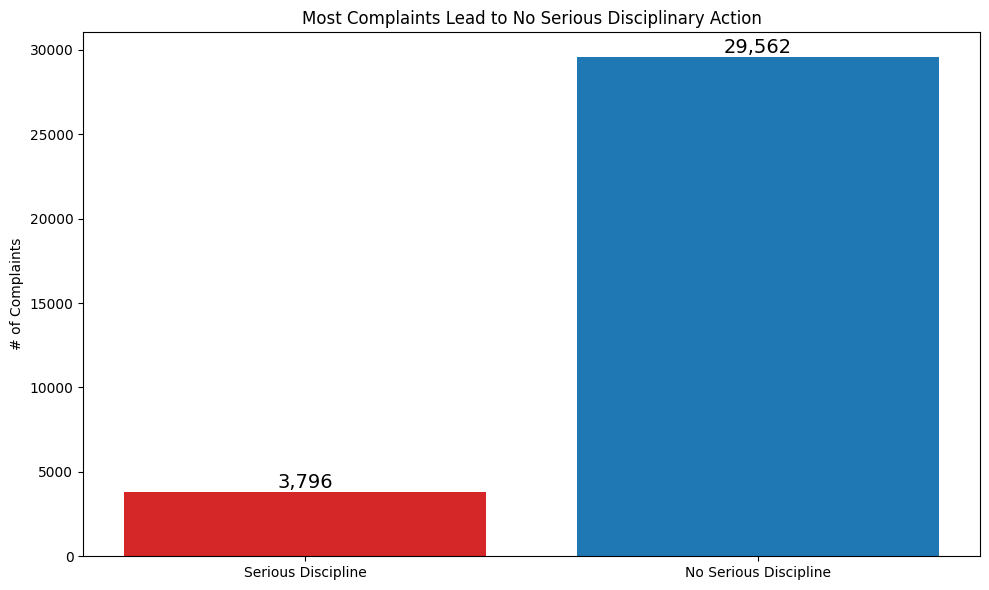

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(['Serious Discipline', 'No Serious Discipline'], 
       [serious, no_serious], 
       color=['#d62728', '#1f77b4'])

ax.set_ylabel('# of Complaints')
ax.set_title('Most Complaints Lead to No Serious Disciplinary Action')

for i, count in enumerate([serious, no_serious]):
    ax.text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=14)
plt.tight_layout()
plt.show()

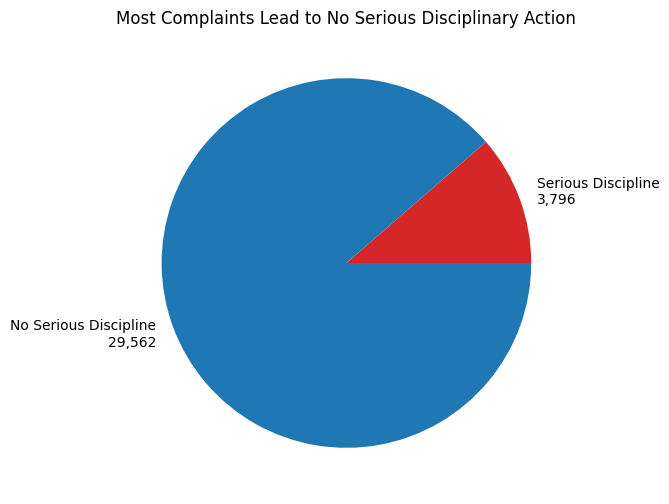

In [8]:

plt.figure(figsize=(6, 6))

plt.pie(
    [serious, no_serious],
    labels=[f'Serious Discipline\n{serious:,}', f'No Serious Discipline\n{no_serious:,}'],
    colors=['#d62728', '#1f77b4']
)

plt.title('Most Complaints Lead to No Serious Disciplinary Action')
plt.show()


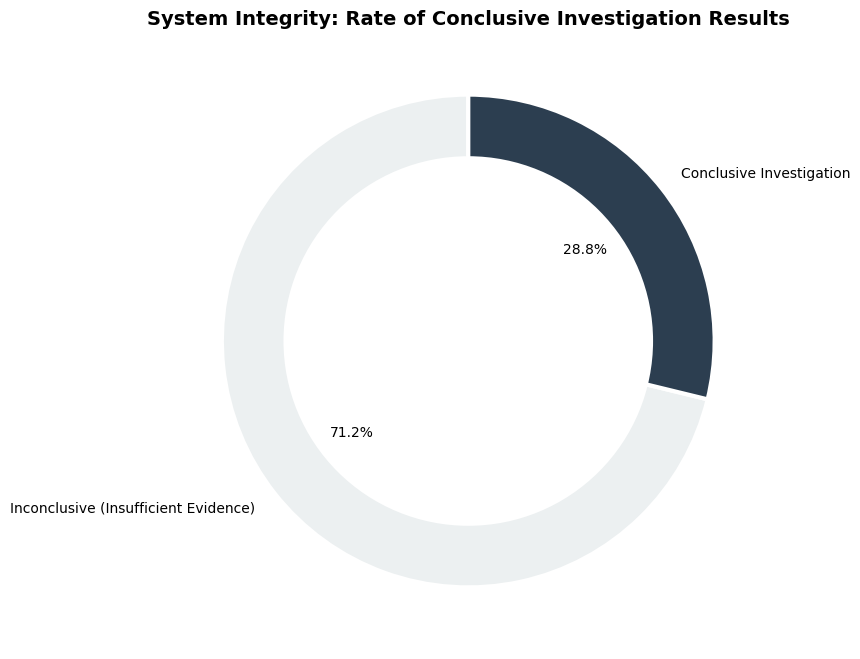

In [12]:
def simplify_side_b(val):
    if val in ['Substantiated', 'Exonerated']:
        return 'Conclusive Investigation' 
    return 'Inconclusive (Insufficient Evidence)'

df['simple_outcome'] = df['board_disposition'].apply(simplify_side_b)
counts = df['simple_outcome'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#ecf0f1', '#2c3e50'] 

ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, 
       colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 3})

ax.add_artist(plt.Circle((0,0), 0.75, fc='white'))

plt.title("System Integrity: Rate of Conclusive Investigation Results", fontsize=14, weight='bold')
plt.show()

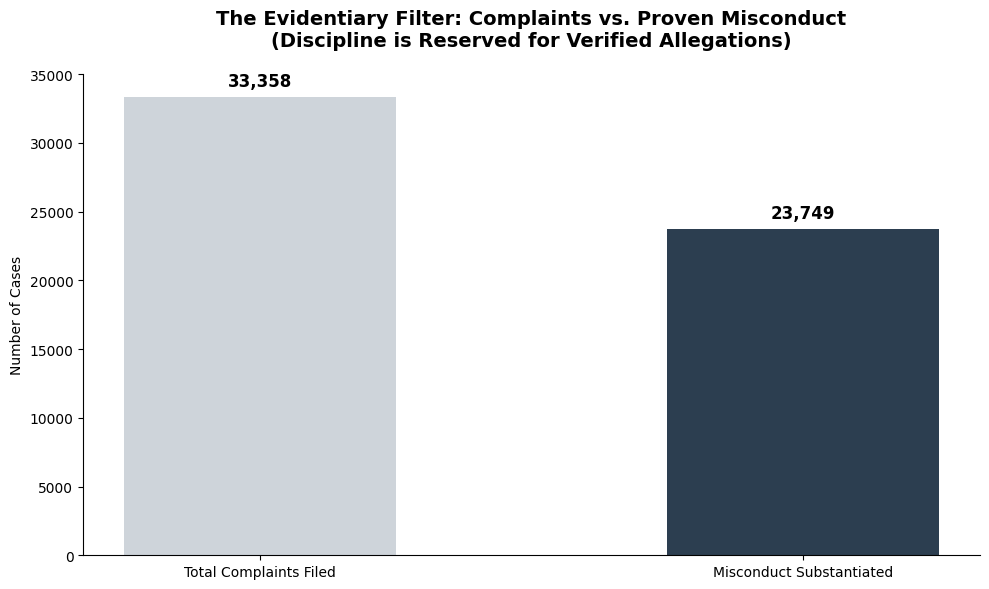

In [42]:
total_complaints = len(df)
substantiated_cases = df['board_disposition'].str.contains('Substantiated', case=False, na=False).sum()

labels = ['Total Complaints Filed', 'Misconduct Substantiated']
values = [total_complaints, substantiated_cases]

plt.figure(figsize=(10, 6), facecolor='white')
colors = ['#ced4da', '#2c3e50'] 

bars = plt.bar(labels, values, color=colors, width=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 500,
             f'{height:,}', ha='center', va='bottom', weight='bold', fontsize=12)

plt.title("The Evidentiary Filter: Complaints vs. Proven Misconduct\n(Discipline is Reserved for Verified Allegations)", 
          fontsize=14, weight='bold', pad=20)
plt.ylabel("Number of Cases")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
import altair as alt

# Data Transformation: Group by FADO type and calculate the "Actionable" rate
# (Substantiated + Exonerated)
source = pd.DataFrame({
    'Category': ['Abuse of Authority', 'Discourtesy', 'Offensive Language', 'Force'],
    'Rate': [30.4, 21.9, 16.9, 12.8] # Replace with your actual calculated rates
})

# Create the Lollipop Chart
base = alt.Chart(source).encode(
    x=alt.X('Rate:Q', title='Percentage of Conclusive Resolutions', scale=alt.Scale(domain=[0, 100])),
    y=alt.Y('Category:N', sort='-x', title='')
)

points = base.mark_point(filled=True, size=200, color='#1a5276')
lines = base.mark_rule(color='#1a5276', strokeWidth=2)

chart = (lines + points).properties(
    title='Rigorous Investigations: Higher Resolution in Documented Categories',
    width=600,
    height=300
).configure_view(strokeWidth=0).configure_axis(grid=False)

chart.display()

alt.LayerChart(...)

/var/folders/70/vjs3hy6j2m54nkfpn71pnwlr0000gn/T/ipykernel_15373/796722471.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


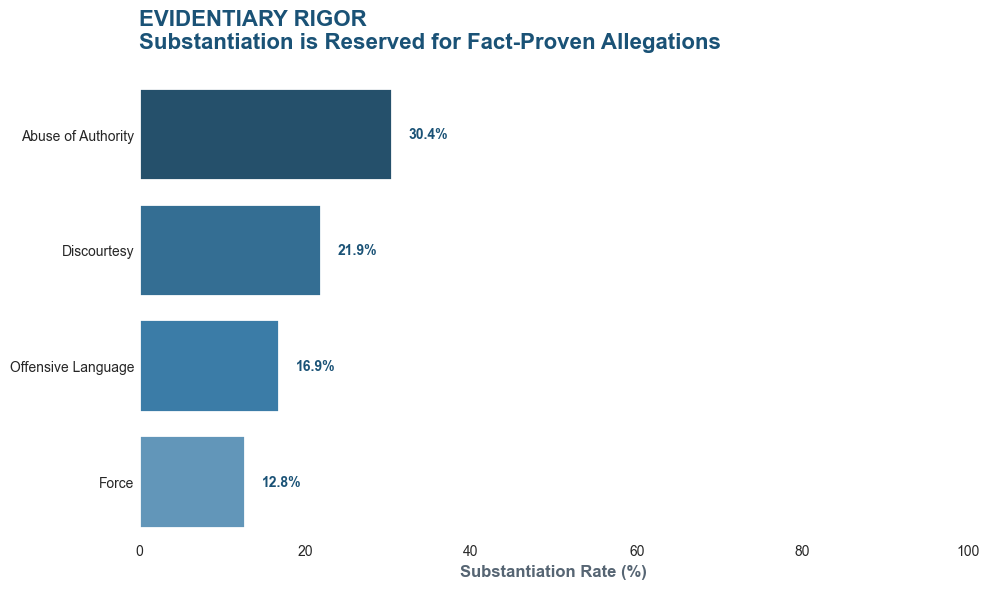

In [9]:
side_b_data = df.groupby('fado_type')['board_disposition'].apply(
    lambda x: (x.str.contains('Substantiated').sum() / len(x)) * 100
).sort_values(ascending=False).reset_index()

# Setup Styling (The "Dashing" Look)
plt.rcParams['font.family'] = 'sans-serif'
plt.figure(figsize=(10, 6), facecolor='white')
sns.set_style("white")

# Plotting with a "Professional Audit" palette
ax = sns.barplot(
    x='board_disposition', y='fado_type', data=side_b_data, 
    palette=['#1a5276', '#2471a3', '#2980b9', '#5499c7'],
    edgecolor='white', linewidth=2
)

# Customizing the details
plt.title("EVIDENTIARY RIGOR\nSubstantiation is Reserved for Fact-Proven Allegations", 
          fontsize=16, weight='bold', loc='left', pad=20, color='#1a5276')
plt.xlabel("Substantiation Rate (%)", fontsize=12, weight='semibold', color='#566573')
plt.ylabel("")
plt.xlim(0, 100) # Full scale demonstrates "transparency" while the data shows "selectivity"

# Remove spines for that modern look
sns.despine(left=True, bottom=True)
ax.tick_params(axis='both', which='both', length=0)

# Add value labels at the end of bars
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%', 
                (p.get_width() + 2, p.get_y() + p.get_height()/2), 
                va='center', weight='bold', color='#1a5276')

plt.tight_layout()
plt.savefig('side_b.png', dpi=300)
plt.show()